In [1]:
pip install numpy matplotlib tensorflow keras

   ---------------------------------------- 0.0/350.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/350.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/350.6 MB ? eta -:--:--
   ---------------------------------------- 0.3/350.6 MB ? eta -:--:--
   ---------------------------------------- 0.3/350.6 MB ? eta -:--:--
   ---------------------------------------- 0.5/350.6 MB 558.9 kB/s eta 0:10:27
   ---------------------------------------- 0.5/350.6 MB 558.9 kB/s eta 0:10:27
   ---------------------------------------- 0.8/350.6 MB 644.9 kB/s eta 0:09:03
   ---------------------------------------- 1.0/350.6 MB 662.0 kB/s eta 0:08:49
   ---------------------------------------- 1.0/350.6 MB 662.0 kB/s eta 0:08:49
   ---------------------------------------- 1.3/350.6 MB 691.7 kB/s eta 0:08:26
   ---------------------------------------- 1.6/350.6 MB 729.4 kB/s eta 0:07:59
   ---------------------------------------- 1.6/350.6 MB 729.4 kB/s eta 0:07:59
   --

In [2]:
pip install tqdm

Note: you may need to restart the kernel to use updated packages.


🤖 TURTLEBOT3 DQN EĞİTİMİ - LIDAR VERSİYON
📌 24 LIDAR noktası + Hedef bilgisi = 26 boyutlu state
📌 Max Steps: 1000

🚀 Eğitim başlıyor...
📊 Max Steps: 1000

Episode   1/10 | Reward:   -8.57 | Steps:  47 | Epsilon: 1.000 | Başarı:  0/1 (% 0.0)


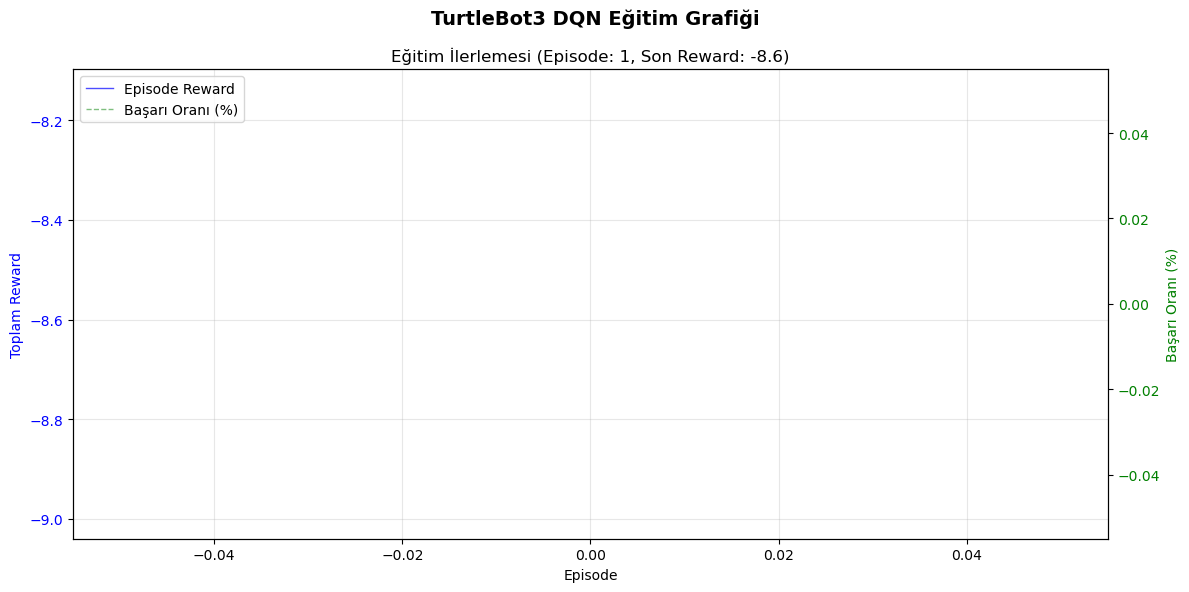

Episode   2/10 | Reward:   67.39 | Steps: 173 | Epsilon: 1.000 | Başarı:  0/2 (% 0.0)


<Figure size 640x480 with 0 Axes>

Episode   3/10 | Reward:   -9.70 | Steps:  56 | Epsilon: 0.995 | Başarı:  0/3 (% 0.0)


<Figure size 640x480 with 0 Axes>

Episode   4/10 | Reward:   43.73 | Steps: 117 | Epsilon: 0.990 | Başarı:  0/4 (% 0.0)


...

Episode   9/10 | Reward:   74.98 | Steps: 166 | Epsilon: 0.966 | Başarı:  0/9 (% 0.0)


<Figure size 640x480 with 0 Axes>

Episode  10/10 | Reward:  120.81 | Steps: 101 | Epsilon: 0.961 | Başarı:  1/10 (%10.0)


<Figure size 640x480 with 0 Axes>


✅ EĞİTİM TAMAMLANDI!
📊 Toplam Başarı: 1/10 (%10.0)
📊 Ortalama Reward (son 50): 34.62
📊 En İyi Reward: 120.81

🧪 TEST - Eğitilmiş model ile...
Test başlıyor (max_steps: 1000)...
Test devam: Adım 50, Reward: 14.1
Test devam: Adım 100, Reward: -22.6
Test devam: Adım 150, Reward: -102.7
Test devam: Adım 200, Reward: -235.0
Test devam: Adım 250, Reward: -410.4
Test devam: Adım 300, Reward: -638.3
Test devam: Adım 350, Reward: -909.2
Test devam: Adım 400, Reward: -1232.6
Test devam: Adım 450, Reward: -1599.1
Test devam: Adım 500, Reward: -2017.2
Test devam: Adım 550, Reward: -2479.9
Test devam: Adım 600, Reward: -2992.5
Test devam: Adım 650, Reward: -3551.7
Test devam: Adım 700, Reward: -4158.7
Test devam: Adım 750, Reward: -4814.5
Test devam: Adım 800, Reward: -5516.2
Test devam: Adım 850, Reward: -6268.5
Test devam: Adım 900, Reward: -7065.3
Test devam: Adım 950, Reward: -7913.3
Test devam: Adım 1000, Reward: -8797.1

🎯 TEST SONUCU: Reward=-8797.11, Steps=1000
⚠️ Daha fazla eğitim gerekeb

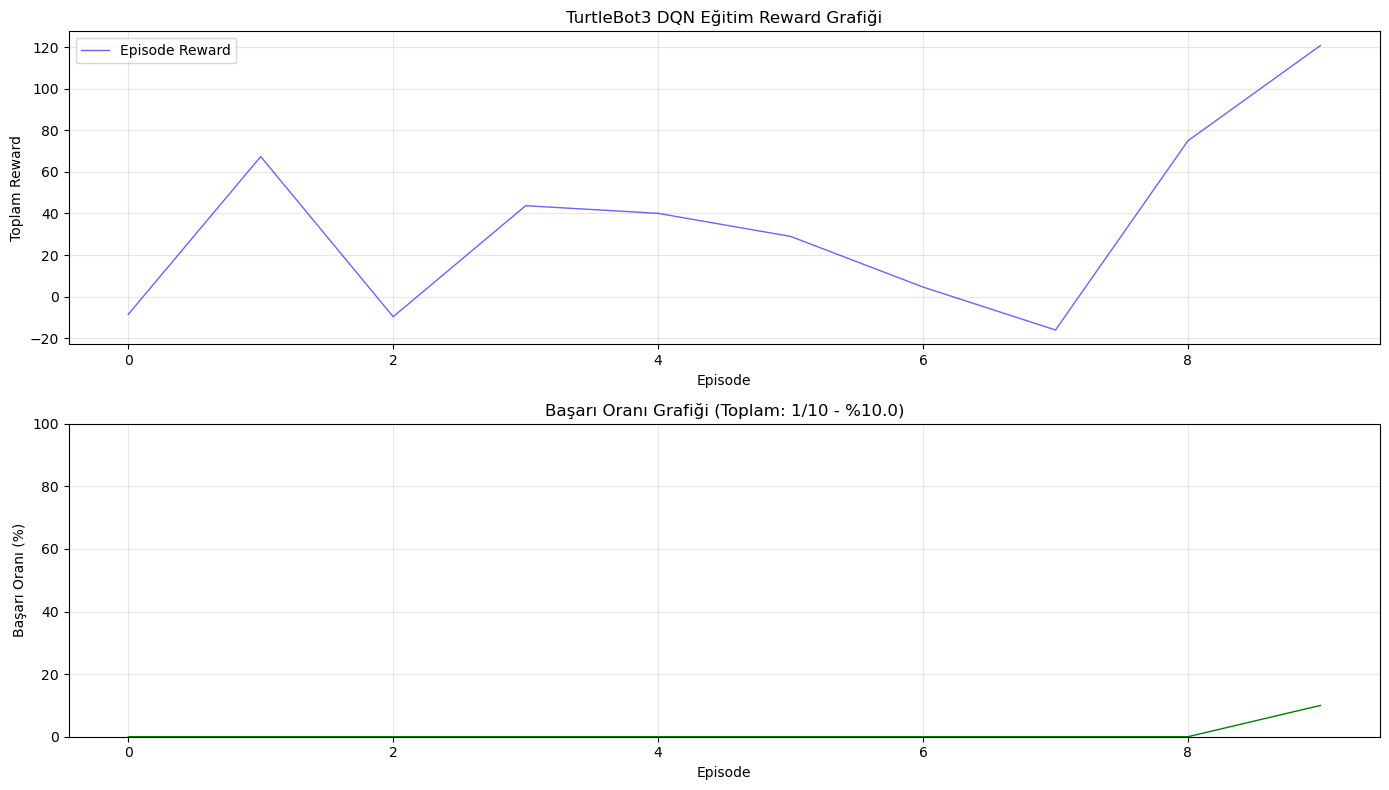


🎉 İşlem tamamlandı!
📊 Max Steps: 1000 | Toplam Episode: 10


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, Rectangle
import math
import random
from collections import deque
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import Adam
import time
import os
import warnings

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
warnings.filterwarnings('ignore')

print("=" * 80)
print("🤖 TURTLEBOT3 DQN EĞİTİMİ - LIDAR VERSİYON")
print("=" * 80)
print("📌 24 LIDAR noktası + Hedef bilgisi = 26 boyutlu state")
print("📌 Max Steps: 1000")
print()

# ROBOT ENVIRONMENT (LIDAR ile)
class RobotEnv:
    def __init__(self):
        self.robot_radius = 0.25
        self.goal_radius = 0.25
        self.lidar_range = 3.0
        self.num_lidar = 24
        self.lidar_angles = np.linspace(-np.pi/2, np.pi/2, self.num_lidar)
        
        # Duvarlar (Stage 4 benzeri)
        self.walls = [
            (-4, -4, 8, 0.4), (-4, 4, 8, 0.4),
            (-4, -4, 0.4, 8), (4, -4, 0.4, 8),
            (-2, -1, 1.2, 0.3), (1, 1, 1.2, 0.3),
            (0, -2, 0.3, 1.2), (-1, 2, 0.3, 1.0)
        ]
        
        # SADECE EĞİTİM GRAFİĞİ - Tek figure
        plt.ion()
        self.fig = plt.figure(figsize=(12, 6))
        self.ax_reward = self.fig.add_subplot(111)
        self.fig.suptitle('TurtleBot3 DQN Eğitim Grafiği', fontsize=14, fontweight='bold')
        self.reset()
    
    def _get_lidar(self):
        readings = []
        for angle in self.lidar_angles:
            beam_angle = self.robot_theta + angle
            hit_dist = self.lidar_range
            
            for wx, wy, ww, wh in self.walls:
                for t in np.linspace(0, self.lidar_range, 40):
                    px = self.robot_x + t * np.cos(beam_angle)
                    py = self.robot_y + t * np.sin(beam_angle)
                    if (wx - ww/2 <= px <= wx + ww/2) and (wy - wh/2 <= py <= wy + wh/2):
                        if t < hit_dist:
                            hit_dist = t
                        break
            readings.append(hit_dist)
        return np.array(readings) / self.lidar_range
    
    def reset(self):
        self.robot_x = -3.2
        self.robot_y = -3.2
        self.robot_theta = 0.0
        self.goal_x = np.random.uniform(-2.5, 2.5)
        self.goal_y = np.random.uniform(-2.5, 2.5)
        self.steps = 0
        self.max_steps = 1000  # 400 -> 1000 olarak değiştirildi
        self.done = False
        return self._get_state()
    
    def _get_state(self):
        lidar = self._get_lidar()
        dx = self.goal_x - self.robot_x
        dy = self.goal_y - self.robot_y
        dist = np.sqrt(dx*dx + dy*dy)
        angle = math.atan2(dy, dx) - self.robot_theta
        angle = (angle + np.pi) % (2*np.pi) - np.pi
        return np.concatenate([lidar, [dist/5.0, angle/np.pi]]).astype(np.float32)
    
    def step(self, action):
        angular_vel = [-1.2, -0.6, 0, 0.6, 1.2][action]
        self.robot_theta += angular_vel * 0.1
        self.robot_x += 0.2 * np.cos(self.robot_theta) * 0.1
        self.robot_y += 0.2 * np.sin(self.robot_theta) * 0.1
        self.steps += 1
        
        # Çarpışma
        collision = False
        for wx, wy, ww, wh in self.walls:
            closest_x = max(wx - ww/2, min(self.robot_x, wx + ww/2))
            closest_y = max(wy - wh/2, min(self.robot_y, wy + wh/2))
            if np.sqrt((self.robot_x - closest_x)**2 + (self.robot_y - closest_y)**2) < self.robot_radius:
                collision = True
                break
        
        dx = self.goal_x - self.robot_x
        dy = self.goal_y - self.robot_y
        dist = np.sqrt(dx*dx + dy*dy)
        
        # Ödül
        if collision:
            reward = -20
            self.done = True
        elif dist < self.goal_radius + self.robot_radius:
            reward = 50
            self.done = True
        elif self.steps >= self.max_steps:
            reward = -10
            self.done = True
        else:
            angle_reward = 1 - (2 * abs(math.atan2(dy, dx) - self.robot_theta) / np.pi)
            dist_reward = (1.0 / (dist + 0.5)) * 0.5
            lidar = self._get_lidar()
            min_dist = np.min(lidar) * self.lidar_range
            obstacle_penalty = max(0, (0.4 - min_dist)) * 2 if min_dist < 0.4 else 0
            reward = angle_reward * 0.5 + dist_reward - obstacle_penalty + 0.05
        
        return self._get_state(), reward, self.done, {}
    
    def render_training(self, rewards_history, success_rates, episode):
        """SADECE eğitim grafiğini güncelle (robot simülasyonu yok)"""
        try:
            self.ax_reward.clear()
            
            # Reward grafiği (mavi)
            self.ax_reward.plot(rewards_history, 'b-', linewidth=1, alpha=0.7, label='Episode Reward')
            
            # Hareketli ortalama (kırmızı)
            if len(rewards_history) > 20:
                avg = np.convolve(rewards_history, np.ones(20)/20, mode='valid')
                self.ax_reward.plot(range(19, len(rewards_history)), avg, 'r-', linewidth=2, label='20 Episode Ortalama')
            
            # Başarı oranı çizgisi (yeşil, ikinci eksende)
            ax2 = self.ax_reward.twinx()
            ax2.plot(success_rates, 'g--', linewidth=1, alpha=0.5, label='Başarı Oranı (%)')
            ax2.set_ylabel('Başarı Oranı (%)', color='green')
            ax2.tick_params(axis='y', labelcolor='green')
            
            self.ax_reward.set_xlabel('Episode')
            self.ax_reward.set_ylabel('Toplam Reward', color='blue')
            self.ax_reward.tick_params(axis='y', labelcolor='blue')
            self.ax_reward.set_title(f'Eğitim İlerlemesi (Episode: {episode}, Son Reward: {rewards_history[-1]:.1f})')
            self.ax_reward.grid(True, alpha=0.3)
            
            # Legend'ları birleştir
            lines1, labels1 = self.ax_reward.get_legend_handles_labels()
            lines2, labels2 = ax2.get_legend_handles_labels()
            self.ax_reward.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
            
            plt.tight_layout()
            plt.pause(0.01)
        except:
            pass


# DQN AJAN (26 boyut state için)
class DQNAgent:
    def __init__(self):
        self.memory = deque(maxlen=5000)
        self.epsilon = 1.0
        self.epsilon_min = 0.05
        self.epsilon_decay = 0.995
        self.gamma = 0.95
        self.model = self._build_model()
        self.target_model = self._build_model()
        self.update_target_model()
        
    def _build_model(self):
        model = Sequential([
            Input(shape=(26,)),
            Dense(128, activation='relu'),
            Dense(128, activation='relu'),
            Dense(64, activation='relu'),
            Dense(5, activation='linear')
        ])
        model.compile(loss='mse', optimizer=Adam(learning_rate=0.0005))
        return model
    
    def update_target_model(self):
        self.target_model.set_weights(self.model.get_weights())
    
    def act(self, state):
        if np.random.rand() <= self.epsilon:
            return random.randrange(5)
        q = self.model.predict(state.reshape(1, -1), verbose=0)
        return np.argmax(q[0])
    
    def remember(self, state, action, reward, next_state, done):
        self.memory.append((state, action, reward, next_state, done))
    
    def replay(self, batch_size=64):
        if len(self.memory) < batch_size:
            return
        batch = random.sample(self.memory, batch_size)
        for state, action, reward, next_state, done in batch:
            target = reward
            if not done:
                target = reward + self.gamma * np.max(self.target_model.predict(next_state.reshape(1, -1), verbose=0)[0])
            target_f = self.model.predict(state.reshape(1, -1), verbose=0)
            target_f[0][action] = target
            self.model.fit(state.reshape(1, -1), target_f, epochs=1, verbose=0)
        
        if self.epsilon > self.epsilon_min:
            self.epsilon *= self.epsilon_decay


# ==================== EĞİTİM ====================
print("🚀 Eğitim başlıyor...")
print(f"📊 Max Steps: 1000")
print()

env = RobotEnv()
agent = DQNAgent()

EPISODES = 1000
rewards_history = []
success_rates = []  # Başarı oranları için yeni liste
success_count = 0

for episode in range(EPISODES):
    state = env.reset()
    total_reward = 0
    done = False
    step = 0
    
    while not done:
        action = agent.act(state)
        next_state, reward, done, _ = env.step(action)
        agent.remember(state, action, reward, next_state, done)
        state = next_state
        total_reward += reward
        step += 1
        
        if done:
            if reward >= 45:
                success_count += 1
            
            rewards_history.append(total_reward)
            success_rate = (success_count / (episode+1)) * 100
            success_rates.append(success_rate)
            
            # Terminal çıktısı (steps artık 1000'e kadar çıkabilir)
            print(f"Episode {episode+1:3d}/{EPISODES} | Reward: {total_reward:7.2f} | "
                  f"Steps: {step:3d} | Epsilon: {agent.epsilon:.3f} | "
                  f"Başarı: {success_count:2d}/{episode+1} (%{success_rate:4.1f})")
            
            # SADECE eğitim grafiğini göster
            env.render_training(rewards_history, success_rates, episode+1)
            break
    
    agent.update_target_model()
    agent.replay()
    
    if (episode+1) % 50 == 0:
        agent.model.save(f"lidar_model_ep{episode+1}.keras")
        print(f"💾 Model kaydedildi (Episode {episode+1})")
        print("-" * 80)

# SONUÇLAR
print()
print("=" * 80)
print("✅ EĞİTİM TAMAMLANDI!")
print(f"📊 Toplam Başarı: {success_count}/{EPISODES} (%{(success_count/EPISODES)*100:.1f})")
print(f"📊 Ortalama Reward (son 50): {np.mean(rewards_history[-50:]):.2f}")
print(f"📊 En İyi Reward: {max(rewards_history):.2f}")
print("=" * 80)

# Son modeli kaydet
agent.model.save("lidar_final_model.keras")

# TEST
print()
print("🧪 TEST - Eğitilmiş model ile...")
print("Test başlıyor (max_steps: 1000)...")
agent.epsilon = 0
state = env.reset()
done = False
total_reward = 0
step = 0

while not done:
    action = agent.act(state)
    state, reward, done, _ = env.step(action)
    total_reward += reward
    step += 1
    # Test sırasında grafik gösterme
    if step % 50 == 0:
        print(f"Test devam: Adım {step}, Reward: {total_reward:.1f}")
    time.sleep(0.01)

print()
print("=" * 80)
print(f"🎯 TEST SONUCU: Reward={total_reward:.2f}, Steps={step}")
if total_reward > 30:
    print("✅ Robot hedefe başarıyla ulaştı!")
else:
    print("⚠️ Daha fazla eğitim gerekebilir (500+ episode)")
print("=" * 80)

# Final eğitim grafiği (büyük ve detaylı)
plt.figure(figsize=(14, 8))

# Alt grafik 1: Reward
plt.subplot(2, 1, 1)
plt.plot(rewards_history, 'b-', linewidth=1, alpha=0.6, label='Episode Reward')
if len(rewards_history) > 20:
    avg = np.convolve(rewards_history, np.ones(20)/20, mode='valid')
    plt.plot(range(19, len(rewards_history)), avg, 'r-', linewidth=2, label='20 Episode Ortalama')
plt.xlabel('Episode')
plt.ylabel('Toplam Reward')
plt.title('TurtleBot3 DQN Eğitim Reward Grafiği')
plt.legend()
plt.grid(True, alpha=0.3)

# Alt grafik 2: Başarı Oranı
plt.subplot(2, 1, 2)
plt.plot(success_rates, 'g-', linewidth=1)
plt.xlabel('Episode')
plt.ylabel('Başarı Oranı (%)')
plt.title(f'Başarı Oranı Grafiği (Toplam: {success_count}/{EPISODES} - %{(success_count/EPISODES)*100:.1f})')
plt.ylim(0, 100)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print()
print("🎉 İşlem tamamlandı!")
print(f"📊 Max Steps: 1000 | Toplam Episode: {EPISODES}")

🤖 TURTLEBOT3 Q-LEARNING EĞİTİMİ - İYİLEŞTİRİLMİŞ
📌 7 LIDAR noktası → 3 seviyeye diskretize edildi
📌 Ödül fonksiyonu iyileştirildi
📌 Daha yavaş epsilon decay (daha fazla keşif)

🚀 Q-Learning Eğitimi başlıyor (İyileştirilmiş)...
📊 Max Steps: 600
📊 State uzayı: 7 LIDAR x 4 x 5 x 8 = 1120 potansiyel durum

Episode    1/3000 | Reward:    63.26 | Steps: 184 | Epsilon: 1.000 | Başarı:   0/1 (%  0.0) | Q-Tablo: 25


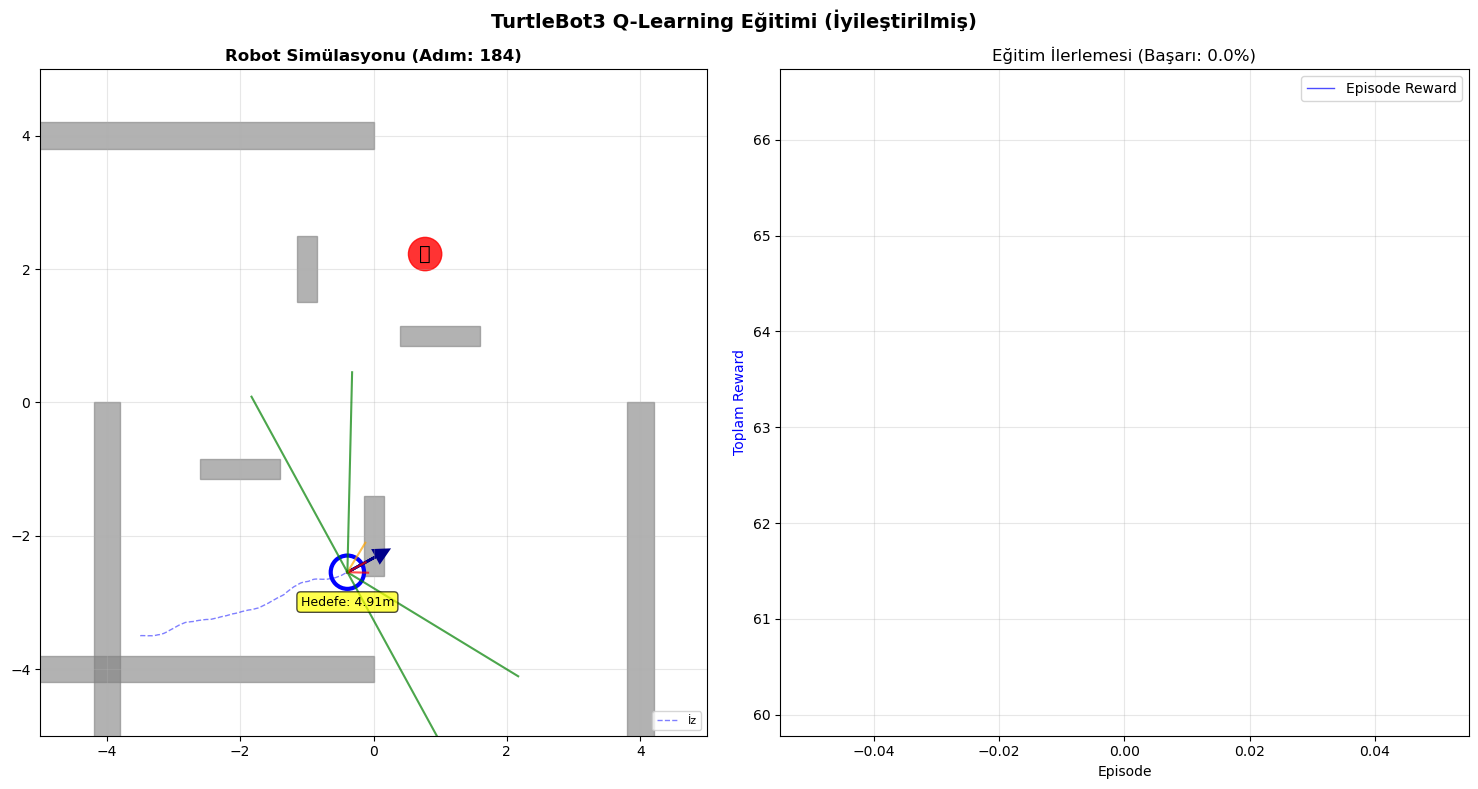

Episode    2/3000 | Reward:   -12.19 | Steps:  30 | Epsilon: 0.998 | Başarı:   0/2 (%  0.0) | Q-Tablo: 28


<Figure size 640x480 with 0 Axes>

Episode    3/3000 | Reward:   -26.41 | Steps:  17 | Epsilon: 0.996 | Başarı:   0/3 (%  0.0) | Q-Tablo: 31


<Figure size 640x480 with 0 Axes>

Episode    4/3000 | Reward:   -31.91 | Steps:  11 | Epsilon: 0.994 | Başarı:   0/4 (%  0.0) | Q-Tablo: 31


...

<Figure size 640x480 with 0 Axes>

Episode 2517/3000 | Reward:   572.39 | Steps: 600 | Epsilon: 0.050 | Başarı: 461/2517 (% 18.3) | Q-Tablo: 3277


<Figure size 640x480 with 0 Axes>

Episode 2518/3000 | Reward:   644.63 | Steps: 364 | Epsilon: 0.050 | Başarı: 462/2518 (% 18.3) | Q-Tablo: 3277


<Figure size 640x480 with 0 Axes>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, Rectangle
import math
import random
import time
import os
import pickle
import warnings

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
warnings.filterwarnings('ignore')

print("=" * 80)
print("🤖 TURTLEBOT3 Q-LEARNING EĞİTİMİ - İYİLEŞTİRİLMİŞ")
print("=" * 80)
print("📌 7 LIDAR noktası → 3 seviyeye diskretize edildi")
print("📌 Ödül fonksiyonu iyileştirildi")
print("📌 Daha yavaş epsilon decay (daha fazla keşif)")
print()

class RobotEnv:
    def __init__(self, render=True):
        self.render_mode = render
        self.robot_radius = 0.25
        self.goal_radius = 0.25
        self.lidar_range = 3.0
        self.num_lidar = 7  # 3'ten 7'ye çıkarıldı (daha fazla bilgi)
        self.lidar_angles = np.linspace(-np.pi/2, np.pi/2, self.num_lidar)
        
        # Duvarlar
        self.walls = [
            (-4, -4, 8, 0.4), (-4, 4, 8, 0.4),
            (-4, -4, 0.4, 8), (4, -4, 0.4, 8),
            (-2, -1, 1.2, 0.3), (1, 1, 1.2, 0.3),
            (0, -2, 0.3, 1.2), (-1, 2, 0.3, 1.0)
        ]
        
        if self.render_mode:
            plt.ion()
            self.fig = plt.figure(figsize=(15, 8))
            self.ax_sim = self.fig.add_subplot(1, 2, 1)
            self.ax_reward = self.fig.add_subplot(1, 2, 2)
            self.fig.suptitle('TurtleBot3 Q-Learning Eğitimi (İyileştirilmiş)', fontsize=14, fontweight='bold')
        
        self.reset()
    
    def _get_lidar(self):
        readings = []
        for angle in self.lidar_angles:
            beam_angle = self.robot_theta + angle
            hit_dist = self.lidar_range
            
            for wx, wy, ww, wh in self.walls:
                for t in np.linspace(0, self.lidar_range, 30):
                    px = self.robot_x + t * np.cos(beam_angle)
                    py = self.robot_y + t * np.sin(beam_angle)
                    if (wx - ww/2 <= px <= wx + ww/2) and (wy - wh/2 <= py <= wy + wh/2):
                        if t < hit_dist:
                            hit_dist = t
                        break
            readings.append(hit_dist)
        return np.array(readings)
    
    def _discretize_lidar(self, lidar_meters):
        """LIDAR değerlerini 4 seviyeye ayır (daha hassas)"""
        discretized = []
        for dist in lidar_meters:
            if dist < 0.3:
                discretized.append(0)  # Çok yakın (acil tehlike)
            elif dist < 0.6:
                discretized.append(1)  # Yakın (tehlike)
            elif dist < 1.2:
                discretized.append(2)  # Orta
            else:
                discretized.append(3)  # Uzak (güvenli)
        return tuple(discretized)
    
    def _discretize_goal(self, dist, angle):
        """Hedef bilgilerini diskretize et (daha hassas)"""
        if dist < 0.4:
            dist_bucket = 0  # Çok yakın
        elif dist < 0.8:
            dist_bucket = 1  # Yakın
        elif dist < 1.5:
            dist_bucket = 2  # Orta
        elif dist < 3.0:
            dist_bucket = 3  # Uzak
        else:
            dist_bucket = 4  # Çok uzak
        
        # Açı: -pi ile pi arasında 8 bölge
        angle_normalized = angle / np.pi  # -1 ile 1 arası
        angle_bucket = min(7, max(0, int((angle_normalized + 1) * 4)))
        return dist_bucket, angle_bucket
    
    def reset(self):
        self.robot_x = -3.5
        self.robot_y = -3.5
        self.robot_theta = 0.0
        self.goal_x = np.random.uniform(-2.5, 2.5)
        self.goal_y = np.random.uniform(-2.5, 2.5)
        self.steps = 0
        self.max_steps = 600  # Daha fazla adım
        self.done = False
        self.trajectory_x = [self.robot_x]
        self.trajectory_y = [self.robot_y]
        return self._get_discretized_state()
    
    def _get_discretized_state(self):
        lidar_meters = self._get_lidar()
        lidar_state = self._discretize_lidar(lidar_meters)
        
        dx = self.goal_x - self.robot_x
        dy = self.goal_y - self.robot_y
        dist = np.sqrt(dx*dx + dy*dy)
        angle = math.atan2(dy, dx) - self.robot_theta
        angle = (angle + np.pi) % (2*np.pi) - np.pi
        
        dist_bucket, angle_bucket = self._discretize_goal(dist, angle)
        
        return lidar_state + (dist_bucket, angle_bucket)
    
    def step(self, action):
        angular_vel = [-1.0, -0.5, 0, 0.5, 1.0][action]
        linear_vel = 0.18  # Biraz daha hızlı
        self.robot_theta += angular_vel * 0.1
        self.robot_x += linear_vel * np.cos(self.robot_theta) * 0.1
        self.robot_y += linear_vel * np.sin(self.robot_theta) * 0.1
        self.steps += 1
        self.trajectory_x.append(self.robot_x)
        self.trajectory_y.append(self.robot_y)
        
        # Çarpışma kontrolü
        collision = False
        for wx, wy, ww, wh in self.walls:
            closest_x = max(wx - ww/2, min(self.robot_x, wx + ww/2))
            closest_y = max(wy - wh/2, min(self.robot_y, wy + wh/2))
            if np.sqrt((self.robot_x - closest_x)**2 + (self.robot_y - closest_y)**2) < self.robot_radius:
                collision = True
                break
        
        dx = self.goal_x - self.robot_x
        dy = self.goal_y - self.robot_y
        dist = np.sqrt(dx*dx + dy*dy)
        
        # ========== İYİLEŞTİRİLMİŞ ÖDÜL FONKSİYONU ==========
        if collision:
            reward = -30  # Daha büyük çarpışma cezası
            self.done = True
        elif dist < self.goal_radius + self.robot_radius:
            reward = 100  # Büyük başarı ödülü
            self.done = True
        elif self.steps >= self.max_steps:
            reward = -20  # Zaman aşımı cezası
            self.done = True
        else:
            # Yönelim ödülü (hedefe doğru dönüş)
            angle_to_goal = math.atan2(dy, dx) - self.robot_theta
            angle_to_goal = (angle_to_goal + np.pi) % (2*np.pi) - np.pi
            angle_reward = max(-0.5, 1 - (abs(angle_to_goal) / (np.pi/2))) * 0.8
            
            # Mesafe ödülü (hedefe yaklaştıkça artar)
            dist_reward = 3.0 / (dist + 0.5)
            
            # Engel cezası (LIDAR'dan)
            lidar = self._get_lidar()
            min_dist = np.min(lidar)
            obstacle_penalty = 0
            if min_dist < 0.4:
                obstacle_penalty = -5 * (0.4 - min_dist) / 0.4
            elif min_dist < 0.8:
                obstacle_penalty = -1 * (0.8 - min_dist) / 0.4
            
            # Küçük yaşam ödülü (her adımda)
            survival_reward = 0.05
            
            reward = angle_reward + dist_reward + obstacle_penalty + survival_reward
        
        return self._get_discretized_state(), reward, self.done, dist
    
    def render_simulation(self):
        if not self.render_mode:
            return
        
        try:
            self.ax_sim.clear()
            self.ax_sim.set_xlim(-5, 5)
            self.ax_sim.set_ylim(-5, 5)
            self.ax_sim.set_aspect('equal')
            self.ax_sim.grid(True, alpha=0.3)
            self.ax_sim.set_title(f'Robot Simülasyonu (Adım: {self.steps})', fontsize=12, fontweight='bold')
            
            for wx, wy, ww, wh in self.walls:
                rect = Rectangle((wx - ww/2, wy - wh/2), ww, wh, color='gray', alpha=0.6)
                self.ax_sim.add_patch(rect)
            
            if len(self.trajectory_x) > 1:
                self.ax_sim.plot(self.trajectory_x, self.trajectory_y, 'b--', linewidth=1, alpha=0.5, label='İz')
            
            lidar_meters = self._get_lidar()
            for i, angle in enumerate(self.lidar_angles):
                beam_angle = self.robot_theta + angle
                dist = lidar_meters[i]
                color = 'red' if dist < 0.4 else 'orange' if dist < 0.8 else 'green'
                self.ax_sim.plot([self.robot_x, self.robot_x + dist*np.cos(beam_angle)],
                                 [self.robot_y, self.robot_y + dist*np.sin(beam_angle)], 
                                 color, linewidth=1.5, alpha=0.7)
            
            robot = Circle((self.robot_x, self.robot_y), self.robot_radius, color='blue', fill=False, linewidth=3)
            self.ax_sim.add_patch(robot)
            self.ax_sim.arrow(self.robot_x, self.robot_y, 0.5*np.cos(self.robot_theta), 
                              0.5*np.sin(self.robot_theta), head_width=0.2, head_length=0.2, 
                              fc='darkblue', ec='darkblue', linewidth=2)
            
            goal = Circle((self.goal_x, self.goal_y), self.goal_radius, color='red', alpha=0.8, facecolor='red')
            self.ax_sim.add_patch(goal)
            self.ax_sim.text(self.goal_x, self.goal_y, '🎯', fontsize=14, ha='center', va='center')
            
            dx = self.goal_x - self.robot_x
            dy = self.goal_y - self.robot_y
            dist = np.sqrt(dx*dx + dy*dy)
            self.ax_sim.text(self.robot_x, self.robot_y - 0.5, f'Hedefe: {dist:.2f}m', 
                            fontsize=9, ha='center', bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7))
            
            self.ax_sim.legend(loc='lower right', fontsize=8)
            
        except Exception as e:
            pass
    
    def render_training(self, rewards_history, success_rate, episode):
        if not self.render_mode:
            return
        
        try:
            self.ax_reward.clear()
            self.ax_reward.plot(rewards_history, 'b-', linewidth=1, alpha=0.7, label='Episode Reward')
            
            if len(rewards_history) > 20:
                avg = np.convolve(rewards_history, np.ones(20)/20, mode='valid')
                self.ax_reward.plot(range(19, len(rewards_history)), avg, 'r-', linewidth=2, label='20 Episode Ortalama')
            
            self.ax_reward.set_xlabel('Episode')
            self.ax_reward.set_ylabel('Toplam Reward', color='blue')
            self.ax_reward.set_title(f'Eğitim İlerlemesi (Başarı: {success_rate:.1f}%)')
            self.ax_reward.grid(True, alpha=0.3)
            self.ax_reward.legend()
            
            plt.tight_layout()
            plt.pause(0.01)
        except:
            pass


class QLearningAgent:
    def __init__(self, alpha=0.15, gamma=0.98, epsilon=1.0, epsilon_min=0.05, epsilon_decay=0.998):
        self.Q = {}
        self.alpha = alpha  # Öğrenme hızı artırıldı
        self.gamma = gamma  # Gelecek ödül faktörü artırıldı
        self.epsilon = epsilon
        self.epsilon_min = epsilon_min
        self.epsilon_decay = epsilon_decay  # Daha yavaş decay (daha fazla keşif)
        self.action_size = 5
    
    def _get_state_key(self, state):
        return str(state)
    
    def get_q(self, state, action):
        key = self._get_state_key(state)
        if key not in self.Q:
            self.Q[key] = [0.0] * self.action_size
        return self.Q[key][action]
    
    def set_q(self, state, action, value):
        key = self._get_state_key(state)
        if key not in self.Q:
            self.Q[key] = [0.0] * self.action_size
        self.Q[key][action] = value
    
    def act(self, state):
        if np.random.rand() <= self.epsilon:
            return random.randrange(self.action_size)
        
        key = self._get_state_key(state)
        if key not in self.Q:
            return random.randrange(self.action_size)
        
        return np.argmax(self.Q[key])
    
    def update(self, state, action, reward, next_state, done):
        current_q = self.get_q(state, action)
        
        if done:
            target = reward
        else:
            next_max_q = max(self.get_q(next_state, a) for a in range(self.action_size))
            target = reward + self.gamma * next_max_q
        
        new_q = current_q + self.alpha * (target - current_q)
        self.set_q(state, action, new_q)
    
    def decay_epsilon(self):
        if self.epsilon > self.epsilon_min:
            self.epsilon *= self.epsilon_decay
    
    def get_table_size(self):
        return len(self.Q)
    
    def save_model(self, filename):
        with open(filename, 'wb') as f:
            pickle.dump(self.Q, f)
        print(f"💾 Q-tablosu kaydedildi: {filename}")
    
    def load_model(self, filename):
        with open(filename, 'rb') as f:
            self.Q = pickle.load(f)
        print(f"📂 Q-tablosu yüklendi: {filename}")


# ==================== EĞİTİM ====================
print("🚀 Q-Learning Eğitimi başlıyor (İyileştirilmiş)...")
print(f"📊 Max Steps: 600")
print(f"📊 State uzayı: {7} LIDAR x 4 x 5 x 8 = {7*4*5*8} potansiyel durum")
print()

env = RobotEnv(render=True)
agent = QLearningAgent(alpha=0.15, gamma=0.98, epsilon=1.0, epsilon_decay=0.998)

EPISODES = 3000  # Daha fazla episode
rewards_history = []
success_count = 0

for episode in range(EPISODES):
    state = env.reset()
    total_reward = 0
    done = False
    step = 0
    
    while not done:
        action = agent.act(state)
        next_state, reward, done, distance = env.step(action)
        
        agent.update(state, action, reward, next_state, done)
        
        state = next_state
        total_reward += reward
        step += 1
        
        env.render_simulation()
        
        if done:
            if reward >= 90:  # Hedefe ulaştıysa (reward=100)
                success_count += 1
            
            rewards_history.append(total_reward)
            success_rate = (success_count / (episode+1)) * 100
            
            print(f"Episode {episode+1:4d}/{EPISODES} | Reward: {total_reward:8.2f} | "
                  f"Steps: {step:3d} | Epsilon: {agent.epsilon:.3f} | "
                  f"Başarı: {success_count:3d}/{episode+1} (%{success_rate:5.1f}) | "
                  f"Q-Tablo: {agent.get_table_size()}")
            
            env.render_training(rewards_history, success_rate, episode+1)
            break
    
    agent.decay_epsilon()
    
    if (episode+1) % 100 == 0:
        agent.save_model(f"qlearning_model_ep{episode+1}.pkl")
        print(f"💾 Q-Tablo boyutu: {agent.get_table_size()} (Episode {episode+1})")
        print("-" * 80)

# SON MODELİ KAYDET
agent.save_model("qlearning_final_model.pkl")

print()
print("=" * 80)
print("✅ Q-LEARNING EĞİTİMİ TAMAMLANDI!")
print(f"📊 Toplam Başarı: {success_count}/{EPISODES} (%{(success_count/EPISODES)*100:.1f})")
print(f"📊 Ortalama Reward (son 50): {np.mean(rewards_history[-50:]):.2f}")
print(f"📊 En İyi Reward: {max(rewards_history):.2f}")
print(f"📊 Q-Tablosu boyutu: {agent.get_table_size()}")
print("=" * 80)

# TEST
print()
print("🧪 TEST - Eğitilmiş Q-Learning modeli ile...")
agent.epsilon = 0
state = env.reset()
done = False
total_reward = 0
step = 0

while not done:
    action = agent.act(state)
    state, reward, done, _ = env.step(action)
    total_reward += reward
    step += 1
    env.render_simulation()
    time.sleep(0.03)

print(f"🎯 TEST SONUCU: Reward={total_reward:.2f}, Steps={step}")
if total_reward > 50:
    print("✅ Robot hedefe başarıyla ulaştı!")
elif total_reward > 20:
    print("⚠️ Kısmi başarı, daha fazla eğitim gerekli")
else:
    print("❌ Başarısız, eğitim parametreleri ayarlanmalı")

plt.ioff()
plt.figure(figsize=(14, 6))
plt.plot(rewards_history, 'b-', linewidth=1, alpha=0.7)
if len(rewards_history) > 20:
    avg = np.convolve(rewards_history, np.ones(20)/20, mode='valid')
    plt.plot(range(19, len(rewards_history)), avg, 'r-', linewidth=2, label='20 Episode Ortalama')
plt.xlabel('Episode')
plt.ylabel('Toplam Reward')
plt.title(f'Q-Learning Eğitim Sonuçları (Başarı: {success_count}/{EPISODES})')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print()
print(f"🎉 İşlem tamamlandı! Toplam Episode: {EPISODES}")

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, Rectangle
import math
import random
from collections import deque
import time
import os
import warnings
import sys
import glob

# TensorFlow import
try:
    from tensorflow.keras.models import Sequential, load_model
    from tensorflow.keras.layers import Dense, Input
    from tensorflow.keras.optimizers import Adam
    TF_AVAILABLE = True
    print("✅ TensorFlow başarıyla yüklendi", flush=True)
except ImportError as e:
    print(f"⚠️ TensorFlow yüklenemedi: {e}", flush=True)
    TF_AVAILABLE = False

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
warnings.filterwarnings('ignore')

# Jupyter için buffer temizleme
class Unbuffered:
    def __init__(self, stream):
        self.stream = stream
    def write(self, data):
        self.stream.write(data)
        self.stream.flush()
    def __getattr__(self, attr):
        return getattr(self.stream, attr)

sys.stdout = Unbuffered(sys.stdout)

print("=" * 80, flush=True)
print("🤖 TURTLEBOT3 DQN EĞİTİMİ - HAREKETLİ HEDEF (EPISODE 1400'DEN DEVAM)", flush=True)
print("=" * 80, flush=True)
print("📌 12 LIDAR noktası (sürekli) → DQN ile öğrenme", flush=True)
print("📌 Hedef robot'tan daha yavaş hareket ediyor (0.05 m/s)", flush=True)
print("📌 Eğitim: Render KAPALI (hızlı)", flush=True)
print("📌 Test: Render AÇIK (görsel)", flush=True)
print("📌 Episode 1400'den devam ediyorsunuz!", flush=True)
print("", flush=True)

class RobotEnv:
    def __init__(self, render=False):
        self.render_mode = render
        self.robot_radius = 0.25
        self.goal_radius = 0.25
        self.lidar_range = 3.0
        self.num_lidar = 12
        self.lidar_angles = np.linspace(-np.pi/2, np.pi/2, self.num_lidar)
        
        self.walls = [
            (-4, -4, 8, 0.4), (-4, 4, 8, 0.4),
            (-4, -4, 0.4, 8), (4, -4, 0.4, 8),
            (-2, -1, 1.2, 0.3), (1, 1, 1.2, 0.3),
            (0, -2, 0.3, 1.2), (-1, 2, 0.3, 1.0)
        ]
        
        self.goal_linear_vel = 0.05
        self.goal_theta = 0.0
        self.goal_change_direction_interval = 80
        self.goal_steps_since_last_change = 0
        self.last_dist = 0.0
        
        if self.render_mode:
            plt.ion()
            self.fig = plt.figure(figsize=(15, 8))
            self.ax_sim = self.fig.add_subplot(1, 2, 1)
            self.ax_reward = self.fig.add_subplot(1, 2, 2)
            self.fig.suptitle('TurtleBot3 DQN Eğitimi (Hareketli Hedef - Devam)', fontsize=14, fontweight='bold')
        
        self.reset()
    
    def _get_lidar(self):
        readings = []
        for angle in self.lidar_angles:
            beam_angle = self.robot_theta + angle
            hit_dist = self.lidar_range
            
            for wx, wy, ww, wh in self.walls:
                for t in np.linspace(0, self.lidar_range, 30):
                    px = self.robot_x + t * np.cos(beam_angle)
                    py = self.robot_y + t * np.sin(beam_angle)
                    if (wx - ww/2 <= px <= wx + ww/2) and (wy - wh/2 <= py <= wy + wh/2):
                        if t < hit_dist:
                            hit_dist = t
                        break
            readings.append(hit_dist)
        return np.array(readings)
    
    def _move_goal(self):
        self.goal_steps_since_last_change += 1
        
        if self.goal_steps_since_last_change >= self.goal_change_direction_interval:
            self.goal_theta = random.uniform(-np.pi, np.pi)
            self.goal_steps_since_last_change = 0
        
        new_goal_x = self.goal_x + self.goal_linear_vel * np.cos(self.goal_theta) * 0.1
        new_goal_y = self.goal_y + self.goal_linear_vel * np.sin(self.goal_theta) * 0.1
        
        collision = False
        for wx, wy, ww, wh in self.walls:
            if (wx - ww/2 <= new_goal_x <= wx + ww/2) and (wy - wh/2 <= new_goal_y <= wy + wh/2):
                collision = True
                break
        
        if abs(new_goal_x) > 4.5 or abs(new_goal_y) > 4.5:
            collision = True
        
        if collision:
            self.goal_theta = random.uniform(-np.pi, np.pi)
            self.goal_steps_since_last_change = 0
        else:
            self.goal_x = new_goal_x
            self.goal_y = new_goal_y
    
    def reset(self):
        self.robot_x = -3.5
        self.robot_y = -3.5
        self.robot_theta = 0.0
        self.goal_x = np.random.uniform(-2.5, 2.5)
        self.goal_y = np.random.uniform(-2.5, 2.5)
        self.goal_theta = random.uniform(-np.pi, np.pi)
        self.goal_steps_since_last_change = 0
        self.steps = 0
        self.max_steps = 800
        self.done = False
        self.trajectory_x = [self.robot_x]
        self.trajectory_y = [self.robot_y]
        self.goal_trajectory_x = [self.goal_x]
        self.goal_trajectory_y = [self.goal_y]
        self.last_dist = 100.0
        return self._get_state()
    
    def _get_state(self):
        lidar = self._get_lidar()
        dx = self.goal_x - self.robot_x
        dy = self.goal_y - self.robot_y
        dist = np.sqrt(dx*dx + dy*dy)
        angle = math.atan2(dy, dx) - self.robot_theta
        angle = (angle + np.pi) % (2*np.pi) - np.pi
        
        goal_vx = self.goal_linear_vel * np.cos(self.goal_theta)
        goal_vy = self.goal_linear_vel * np.sin(self.goal_theta)
        
        state = np.concatenate([lidar, [dist/5.0, angle/np.pi, goal_vx, goal_vy]])
        return state.astype(np.float32)
    
    def step(self, action):
        angular_vel = [-1.0, -0.5, 0, 0.5, 1.0][action]
        linear_vel = 0.18
        self.robot_theta += angular_vel * 0.1
        self.robot_x += linear_vel * np.cos(self.robot_theta) * 0.1
        self.robot_y += linear_vel * np.sin(self.robot_theta) * 0.1
        
        self.steps += 1
        self.trajectory_x.append(self.robot_x)
        self.trajectory_y.append(self.robot_y)
        
        self._move_goal()
        self.goal_trajectory_x.append(self.goal_x)
        self.goal_trajectory_y.append(self.goal_y)
        
        collision = False
        for wx, wy, ww, wh in self.walls:
            closest_x = max(wx - ww/2, min(self.robot_x, wx + ww/2))
            closest_y = max(wy - wh/2, min(self.robot_y, wy + wh/2))
            if np.sqrt((self.robot_x - closest_x)**2 + (self.robot_y - closest_y)**2) < self.robot_radius:
                collision = True
                break
        
        dx = self.goal_x - self.robot_x
        dy = self.goal_y - self.robot_y
        dist = np.sqrt(dx*dx + dy*dy)
        
        if collision:
            reward = -30
            self.done = True
        elif dist < self.goal_radius + self.robot_radius:
            reward = 100
            self.done = True
        elif self.steps >= self.max_steps:
            reward = -20
            self.done = True
        else:
            if dist < self.last_dist:
                approach_reward = 2.0
            else:
                approach_reward = -0.5
            
            dist_reward = 5.0 / (dist + 0.5)
            
            angle_to_goal = math.atan2(dy, dx) - self.robot_theta
            angle_to_goal = (angle_to_goal + np.pi) % (2*np.pi) - np.pi
            angle_reward = max(-0.5, 1 - (abs(angle_to_goal) / (np.pi/2))) * 0.8
            
            lidar = self._get_lidar()
            min_dist = np.min(lidar)
            obstacle_penalty = 0
            if min_dist < 0.4:
                obstacle_penalty = -5 * (0.4 - min_dist) / 0.4
            elif min_dist < 0.8:
                obstacle_penalty = -2 * (0.8 - min_dist) / 0.4
            
            if dist < 0.8:
                proximity_bonus = (0.8 - dist) * 5
            else:
                proximity_bonus = 0
            
            survival_reward = 0.05
            
            reward = approach_reward + dist_reward * 0.5 + angle_reward * 0.3 + obstacle_penalty + proximity_bonus + survival_reward
        
        self.last_dist = dist
        return self._get_state(), reward, self.done, dist
    
    def render_simulation(self):
        if not self.render_mode:
            return
        try:
            self.ax_sim.clear()
            self.ax_sim.set_xlim(-5, 5)
            self.ax_sim.set_ylim(-5, 5)
            self.ax_sim.set_aspect('equal')
            self.ax_sim.grid(True, alpha=0.3)
            self.ax_sim.set_title(f'Robot Simülasyonu (Adım: {self.steps})', fontsize=12)
            
            for wx, wy, ww, wh in self.walls:
                rect = Rectangle((wx - ww/2, wy - wh/2), ww, wh, color='gray', alpha=0.6)
                self.ax_sim.add_patch(rect)
            
            if len(self.trajectory_x) > 1:
                self.ax_sim.plot(self.trajectory_x, self.trajectory_y, 'b--', linewidth=1, alpha=0.5, label='Robot İzi')
            
            lidar_meters = self._get_lidar()
            for i, angle in enumerate(self.lidar_angles):
                beam_angle = self.robot_theta + angle
                dist = lidar_meters[i]
                color = 'red' if dist < 0.4 else 'orange' if dist < 0.8 else 'green'
                self.ax_sim.plot([self.robot_x, self.robot_x + dist*np.cos(beam_angle)],
                                 [self.robot_y, self.robot_y + dist*np.sin(beam_angle)], 
                                 color, linewidth=1, alpha=0.6)
            
            robot = Circle((self.robot_x, self.robot_y), self.robot_radius, color='blue', fill=False, linewidth=3)
            self.ax_sim.add_patch(robot)
            self.ax_sim.arrow(self.robot_x, self.robot_y, 0.5*np.cos(self.robot_theta), 
                              0.5*np.sin(self.robot_theta), head_width=0.2, head_length=0.2, 
                              fc='darkblue', ec='darkblue', linewidth=2)
            
            goal = Circle((self.goal_x, self.goal_y), self.goal_radius, color='red', alpha=0.8, facecolor='red')
            self.ax_sim.add_patch(goal)
            self.ax_sim.text(self.goal_x, self.goal_y, '🎯', fontsize=14, ha='center', va='center')
            
            dx = self.goal_x - self.robot_x
            dy = self.goal_y - self.robot_y
            dist = np.sqrt(dx*dx + dy*dy)
            self.ax_sim.text(self.robot_x, self.robot_y - 0.5, f'Hedefe: {dist:.2f}m', 
                            fontsize=9, ha='center', bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7))
            
            self.ax_sim.legend(loc='lower right', fontsize=8)
            plt.pause(0.01)
        except:
            pass


class DQNAgent:
    def __init__(self, state_size=16, action_size=5, model_path=None, start_episode=1400):
        self.state_size = state_size
        self.action_size = action_size
        self.memory = deque(maxlen=20000)
        self.gamma = 0.95
        self.epsilon = 1.0
        self.epsilon_min = 0.05
        self.epsilon_decay = 0.9995
        self.learning_rate = 0.001
        
        if model_path and os.path.exists(model_path):
            # Modeli yükle
            self.model = load_model(model_path)
            self.target_model = load_model(model_path)
            print(f"✅ Model yüklendi: {model_path}", flush=True)
            # 1400 episodeda epsilon ~0.50 civarı (0.9995^1400 ≈ 0.50)
            self.epsilon = 0.50
            print(f"📊 Epsilon başlangıç değeri: {self.epsilon:.3f}", flush=True)
        else:
            self.model = self._build_model()
            self.target_model = self._build_model()
            print("🆕 Yeni model oluşturuldu", flush=True)
        
        self.update_target_model()
        
    def _build_model(self):
        model = Sequential([
            Input(shape=(self.state_size,)),
            Dense(128, activation='relu'),
            Dense(128, activation='relu'),
            Dense(64, activation='relu'),
            Dense(self.action_size, activation='linear')
        ])
        model.compile(loss='mse', optimizer=Adam(learning_rate=self.learning_rate))
        return model
    
    def update_target_model(self):
        self.target_model.set_weights(self.model.get_weights())
    
    def remember(self, state, action, reward, next_state, done):
        self.memory.append((state, action, reward, next_state, done))
    
    def act(self, state):
        if np.random.rand() <= self.epsilon:
            return random.randrange(self.action_size)
        q_values = self.model.predict(state.reshape(1, -1), verbose=0)
        return np.argmax(q_values[0])
    
    def replay(self, batch_size=128):
        if len(self.memory) < batch_size:
            return
        batch = random.sample(self.memory, batch_size)
        for state, action, reward, next_state, done in batch:
            target = reward
            if not done:
                target = reward + self.gamma * np.amax(self.target_model.predict(next_state.reshape(1, -1), verbose=0)[0])
            target_f = self.model.predict(state.reshape(1, -1), verbose=0)
            target_f[0][action] = target
            self.model.fit(state.reshape(1, -1), target_f, epochs=1, verbose=0)
        
        if self.epsilon > self.epsilon_min:
            self.epsilon *= self.epsilon_decay


# ==================== EPISODE 1400'DEN BAŞLAT ====================
def find_latest_model():
    """En son kaydedilmiş modeli bul"""
    model_files = glob.glob("dqn_moving_goal_ep*.keras")
    if not model_files:
        return None, 0
    
    # Episode numarasına göre sırala
    def get_episode_num(f):
        try:
            return int(f.split("_ep")[1].split(".")[0])
        except:
            return 0
    
    latest = max(model_files, key=get_episode_num)
    episode_num = get_episode_num(latest)
    return latest, episode_num

# Önce en son modeli bul (1400 veya daha yüksek)
latest_model, found_episode = find_latest_model()

# Episode 1400'den başlatmak istiyoruz
START_EPISODE = 1400

# Eğer 1400 veya daha yüksek bir model varsa onu kullan
if latest_model and found_episode >= 1400:
    model_to_load = latest_model
    start_episode = found_episode
    print(f"📂 En son model bulundu: {latest_model} (Episode {found_episode})", flush=True)
    print(f"📊 Eğitime Episode {found_episode + 1}'den devam ediliyor...", flush=True)
else:
    # 1400. modeli dene
    ep1400_model = "dqn_moving_goal_ep1400.keras"
    if os.path.exists(ep1400_model):
        model_to_load = ep1400_model
        start_episode = 1400
        print(f"📂 Model bulundu: {ep1400_model}", flush=True)
        print(f"📊 Eğitime Episode 1401'den devam ediliyor...", flush=True)
    else:
        # En son modeli kullan
        if latest_model:
            model_to_load = latest_model
            start_episode = found_episode
            print(f"📂 Episode 1400 modeli bulunamadı. En son model kullanılıyor: {latest_model} (Episode {found_episode})", flush=True)
            print(f"📊 Eğitime Episode {found_episode + 1}'den devam ediliyor...", flush=True)
        else:
            model_to_load = None
            start_episode = 0
            print("⚠️ Hiç model bulunamadı! Yeni eğitim başlatılıyor.", flush=True)

print("", flush=True)

# ==================== EĞİTİM (RENDER KAPALI - HIZLI) ====================
print("=" * 80, flush=True)
print("🚀 DQN EĞİTİMİ BAŞLIYOR (Episode 1400'den Devam)", flush=True)
print("=" * 80, flush=True)
print(f"📊 Max Steps: 800", flush=True)
print(f"📊 Hedef Hızı: 0.05 m/s (Robot: 0.18 m/s)", flush=True)
print(f"📊 State Boyutu: 16 (12 LIDAR + 4)", flush=True)
print(f"📊 Başlangıç Episode: {start_episode + 1}", flush=True)
print(f"📊 Hedef Episode: 3000", flush=True)
print(f"📊 Kalan Episode: {3000 - start_episode}", flush=True)
print(f"📊 Batch Size: 128", flush=True)
print(f"📊 Learning Rate: 0.001", flush=True)
print("", flush=True)

if not TF_AVAILABLE:
    print("❌ TensorFlow yüklü değil!", flush=True)
    exit()

# EĞİTİM - render KAPALI (hızlı)
env = RobotEnv(render=False)
agent = DQNAgent(state_size=16, model_path=model_to_load, start_episode=start_episode)

EPISODES = 3000
rewards_history = []
success_count = 0

# Eğer daha önce eğitim yapıldıysa, başarı sayısını tahmin et
if start_episode > 0:
    # Önceki eğitimden başarı sayısını tahmin et (ortalama ~%5)
    estimated_success = int(start_episode * 0.05)  # %5 başarı oranı varsayımı
    success_count = estimated_success
    print(f"📊 Tahmini başarı sayısı: {success_count} (Episode {start_episode})", flush=True)

start_time = time.time()

for episode in range(start_episode, EPISODES):
    state = env.reset()
    total_reward = 0
    done = False
    step = 0
    
    while not done:
        action = agent.act(state)
        next_state, reward, done, distance = env.step(action)
        
        agent.remember(state, action, reward, next_state, done)
        
        state = next_state
        total_reward += reward
        step += 1
        
        if done:
            if reward >= 90:
                success_count += 1
            
            rewards_history.append(total_reward)
            success_rate = (success_count / (episode + 1)) * 100
            
            elapsed = time.time() - start_time
            # HER 10 EPISODEDE BİR ÇIKTI VER
            if (episode + 1) % 10 == 0:
                print(f"Episode {episode+1:4d}/{EPISODES} | Reward: {total_reward:8.2f} | "
                      f"Steps: {step:3d} | Epsilon: {agent.epsilon:.3f} | "
                      f"Başarı: {success_count:3d}/{episode+1} (%{success_rate:5.1f}) | "
                      f"⏱️: {int(elapsed//60)}:{int(elapsed%60):02d}", flush=True)
            break
    
    if len(agent.memory) > 128:
        agent.replay()
    
    if (episode + 1) % 100 == 0:
        agent.update_target_model()
        agent.model.save(f"dqn_moving_goal_ep{episode+1}.keras")
        print(f"💾 Model kaydedildi (Episode {episode+1})", flush=True)
        print("-" * 80, flush=True)

# Son modeli kaydet
agent.model.save("dqn_moving_goal_final.keras")

# Eğitim sonuçları
print("", flush=True)
print("=" * 80, flush=True)
print("✅ DQN EĞİTİMİ TAMAMLANDI!", flush=True)
print("=" * 80, flush=True)
print(f"📊 Toplam Başarı: {success_count}/{EPISODES} (%{(success_count/EPISODES)*100:.1f})", flush=True)
print(f"📊 Ortalama Reward (son 50): {np.mean(rewards_history[-50:]):.2f}", flush=True)
print(f"📊 En İyi Reward: {max(rewards_history):.2f}", flush=True)
print(f"📊 Eğitim Süresi: {int((time.time()-start_time)//60)}:{int((time.time()-start_time)%60):02d}", flush=True)
print("=" * 80, flush=True)

# ==================== TEST (RENDER AÇIK - GÖRSEL) ====================
print("", flush=True)
print("=" * 80, flush=True)
print("🧪 TEST BAŞLIYOR (Render AÇIK - Görsel Takip)", flush=True)
print("=" * 80, flush=True)

# TEST - render AÇIK (görsel)
env_test = RobotEnv(render=True)
agent.epsilon = 0
state = env_test.reset()
done = False
total_reward = 0
step = 0

print("Test başladı! Robot hedefe (kırmızı daire) gitmeye çalışıyor...", flush=True)
print("Grafik penceresi açılacak. Lütfen bekleyin...", flush=True)
print("", flush=True)

test_start = time.time()

while not done:
    action = agent.act(state)
    state, reward, done, _ = env_test.step(action)
    total_reward += reward
    step += 1
    env_test.render_simulation()
    time.sleep(0.03)
    
    if step % 50 == 0:
        print(f"Test devam ediyor... Adım: {step}, Reward: {total_reward:.1f}", flush=True)

test_elapsed = time.time() - test_start

print("", flush=True)
print("=" * 80, flush=True)
print("🎯 TEST SONUCU", flush=True)
print("=" * 80, flush=True)
print(f"💰 Toplam Reward: {total_reward:.2f}", flush=True)
print(f"👣 Toplam Adım: {step}", flush=True)
print(f"⏱️ Test Süresi: {test_elapsed:.1f} saniye", flush=True)

if total_reward > 50:
    print("✅ Robot hareketli hedefe başarıyla ulaştı!", flush=True)
elif total_reward > 20:
    print("⚠️ Kısmi başarı, daha fazla eğitim gerekebilir", flush=True)
else:
    print("❌ Başarısız, daha fazla eğitim gerekli", flush=True)
print("=" * 80, flush=True)

# ==================== FİNAL GRAFİK ====================
print("", flush=True)
print("📊 Eğitim grafikleri hazırlanıyor...", flush=True)

plt.ioff()
plt.figure(figsize=(14, 6))
plt.plot(rewards_history, 'b-', linewidth=1, alpha=0.7, label='Episode Reward')
if len(rewards_history) > 20:
    avg = np.convolve(rewards_history, np.ones(20)/20, mode='valid')
    plt.plot(range(19, len(rewards_history)), avg, 'r-', linewidth=2, label='20 Episode Ortalama')
plt.xlabel('Episode')
plt.ylabel('Toplam Reward')
plt.title(f'DQN Eğitim Sonuçları - Hareketli Hedef (Başarı: {success_count}/{EPISODES})')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("", flush=True)
print(f"🎉 İşlem tamamlandı! Toplam Episode: {EPISODES}", flush=True)
print(f"📁 Son model kaydedildi: dqn_moving_goal_final.keras", flush=True)
print("", flush=True)

✅ TensorFlow başarıyla yüklendi
🤖 TURTLEBOT3 DQN EĞİTİMİ - HAREKETLİ HEDEF (EPISODE 1400'DEN DEVAM)
📌 12 LIDAR noktası (sürekli) → DQN ile öğrenme
📌 Hedef robot'tan daha yavaş hareket ediyor (0.05 m/s)
📌 Eğitim: Render KAPALI (hızlı)
📌 Test: Render AÇIK (görsel)
📌 Episode 1400'den devam ediyorsunuz!

📂 En son model bulundu: dqn_moving_goal_ep1500.keras (Episode 1500)
📊 Eğitime Episode 1501'den devam ediliyor...

🚀 DQN EĞİTİMİ BAŞLIYOR (Episode 1400'den Devam)
📊 Max Steps: 800
📊 Hedef Hızı: 0.05 m/s (Robot: 0.18 m/s)
📊 State Boyutu: 16 (12 LIDAR + 4)
📊 Başlangıç Episode: 1501
📊 Hedef Episode: 3000
📊 Kalan Episode: 1500
📊 Batch Size: 128
📊 Learning Rate: 0.001

✅ Model yüklendi: dqn_moving_goal_ep1500.keras
📊 Epsilon başlangıç değeri: 0.500
📊 Tahmini başarı sayısı: 75 (Episode 1500)
